In [27]:
import numpy as np
import pandas as pd
import joblib
import matplotlib.pyplot as plt

from tensorflow.keras.models import load_model

from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    classification_report
)

In [28]:
# Load test data - X_test is scaled (for LR/LSTM), X_test_unscaled for DT/RF
X_test = np.load("../models/X_test.npy")
X_test_unscaled = np.load("../models/X_test_unscaled.npy")
y_test = np.load("../models/y_test.npy")

target_encoder = joblib.load("../models/target_encoder.pkl")

In [29]:
# Load models
lr = joblib.load("../models/logistic_regression.pkl")
dt = joblib.load("../models/decision_tree.pkl")
rf = joblib.load("../models/random_forest.pkl")
lstm_model = load_model("../models/lstm_model.keras")

In [30]:
# Get predictions - use correct data for each model
lr_pred = lr.predict(X_test)  # Scaled data for Logistic Regression
dt_pred = dt.predict(X_test_unscaled)  # Unscaled data for Decision Tree
rf_pred = rf.predict(X_test_unscaled)  # Unscaled data for Random Forest

# LSTM uses scaled data reshaped
X_test_lstm = X_test.reshape(X_test.shape[0], 1, X_test.shape[1])
lstm_pred_prob = lstm_model.predict(X_test_lstm)
lstm_pred = np.argmax(lstm_pred_prob, axis=1)

C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but DecisionTreeClassifier was fitted with feature names
  warnings.warn(
C:\Users\Hussain\AppData\Roaming\Python\Python313\site-packages\sklearn\utils\validation.py:2749: UserWarning: X does not have valid feature names, but RandomForestClassifier was fitted with feature names
  warnings.warn(


94/94 ━━━━━━━━━━━━━━━━━━━━ 1s 5ms/step


In [31]:
def evaluate(name, y_true, y_pred):
    accuracy = accuracy_score(y_true, y_pred)
    precision = precision_score(y_true, y_pred, average="weighted")
    recall = recall_score(y_true, y_pred, average="weighted")
    f1 = f1_score(y_true, y_pred, average="weighted")
    
    return {
        "Model": name,
        "Accuracy": accuracy,
        "Precision": precision,
        "Recall": recall,
        "F1 Score": f1
    }

In [32]:
results = []

results.append(evaluate("Logistic Regression", y_test, lr_pred))
results.append(evaluate("Decision Tree", y_test, dt_pred))
results.append(evaluate("Random Forest", y_test, rf_pred))
results.append(evaluate("LSTM", y_test, lstm_pred))

results = pd.DataFrame(results)
results = results.sort_values(by="Accuracy", ascending=False)

results.style.format({
    "Accuracy": "{:.2%}",
    "Precision": "{:.2%}",
    "Recall": "{:.2%}",
    "F1 Score": "{:.2%}"
})

results

,Model,Accuracy,Precision,Recall,F1 Score
3,LSTM,0.888000,0.888678,0.888000,0.887654
0,Logistic Regression,0.882667,0.882453,0.882667,0.882395
2,Random Forest,0.865333,0.866232,0.865333,0.864363
1,Decision Tree,0.853000,0.852345,0.853000,0.852410


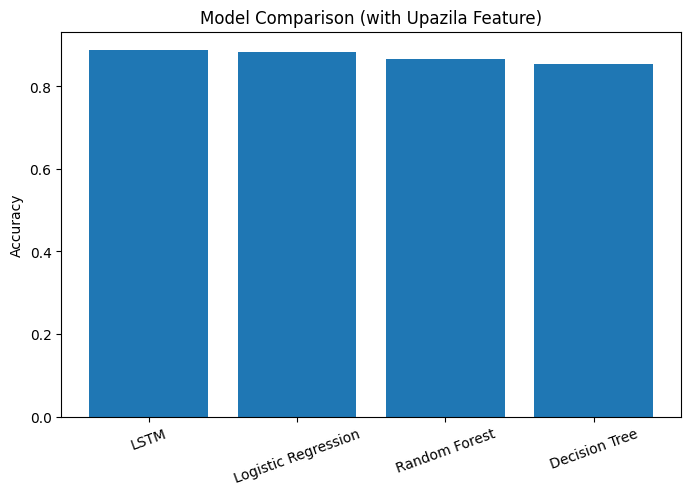

In [33]:
plt.figure(figsize=(8,5))
plt.bar(results["Model"], results["Accuracy"])
plt.ylabel("Accuracy")
plt.title("Model Comparison (with Upazila Feature)")
plt.xticks(rotation=20)
plt.show()

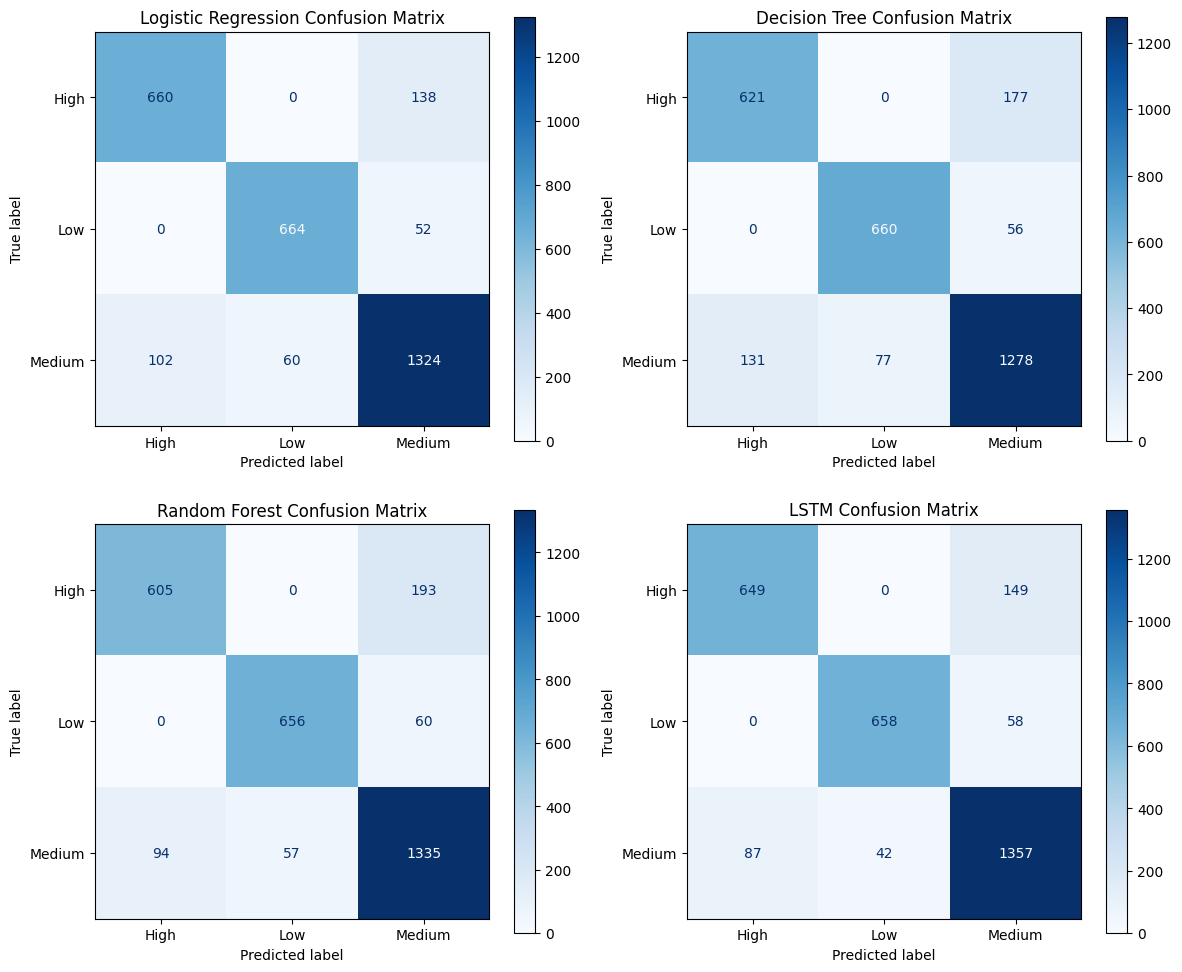

In [34]:
# Plot confusion matrices for all models
fig, axes = plt.subplots(2, 2, figsize=(12, 10))

models_preds = [
    ("Logistic Regression", lr_pred),
    ("Decision Tree", dt_pred),
    ("Random Forest", rf_pred),
    ("LSTM", lstm_pred)
]

for idx, (name, pred) in enumerate(models_preds):
    ax = axes[idx // 2, idx % 2]
    cm = confusion_matrix(y_test, pred)
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=target_encoder.classes_)
    disp.plot(ax=ax, cmap=plt.cm.Blues, values_format='d')
    ax.set_title(f'{name} Confusion Matrix')

plt.tight_layout()
plt.show()

In [35]:
print("\nLSTM Model Architecture:")
print("Total Parameters:", lstm_model.count_params())

lstm_model.summary()


LSTM Model Architecture:
Total Parameters: 128515


Model: "sequential_4"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ lstm_7 (LSTM)                   │ (None, 1, 128)         │        76,800 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_11 (Dropout)            │ (None, 1, 128)         │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ lstm_8 (LSTM)                   │ (None, 64)             │        49,408 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_12 (Dropout)            │ (None, 64)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_8 (Dense)                 │ (None, 32)             │         2,080 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ batch_normalization_4           │ (None, 32)             │           128 │
│ (BatchNormalization)            │                        │               │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dropout_13 (Dropout)            │ (None, 32)             │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_9 (Dense)                 │ (None, 3)              │            99 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 385,419 (1.47 MB)

 Trainable params: 128,451 (501.76 KB)

 Non-trainable params: 64 (256.00 B)

 Optimizer params: 256,904 (1003.54 KB)